In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import BaggingClassifier 
from sklearn.metrics import accuracy_score
from sklearn.ensemble import AdaBoostClassifier
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('sample_data.csv')

In [5]:
X = df[['Hours_Studied', 'Attendance', 'Prev_score', 'Final_marks']]
y = df['Pass']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)   

In [7]:
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

print("=== Bagging Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))

=== Bagging Results ===
Accuracy: 1.0


In [8]:
boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner
    n_estimators=50,
    random_state=42
)

boost_model.fit(X_train, y_train)

y_pred_boost = boost_model.predict(X_test)

print("\n=== Boosting Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))


=== Boosting Results ===
Accuracy: 1.0


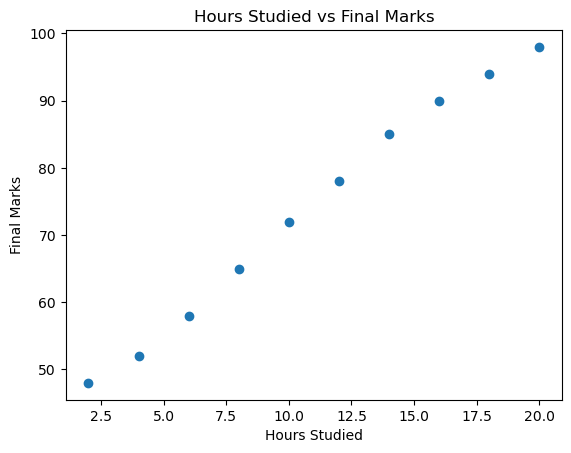

In [9]:
plt.figure()
plt.scatter(df['Hours_Studied'], df['Final_marks'])
plt.xlabel("Hours Studied")
plt.ylabel("Final Marks")
plt.title("Hours Studied vs Final Marks")
plt.show()

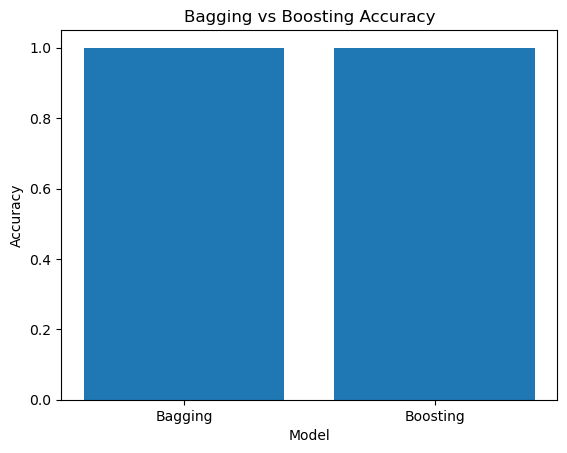

In [10]:
models = ['Bagging', 'Boosting']
accuracies = [
    accuracy_score(y_test, y_pred_bag),
    accuracy_score(y_test, y_pred_boost)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Bagging vs Boosting Accuracy")
plt.show()